# Polynomial Regression

In this notebook we will compare different regression models in order to assess which model fits best. We will be using polynomial regression as a means to examine this topic. In particular we will:
- Write a function to take an an array and a degree and return a data frame where each column is the array to a polynomial value up to the total degree.
- Use a plotting tool to visualize polynomial regressions
- Use a plotting tool to visualize the same polynomial degree on different subsets of the data
- Use a validation set to select a polynomial degree
- Assess the final fit using test data

## Loading Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## Helping Fucntions

You’re going to write a function that adds powers of a feature to columns of a data frame.

In [2]:
def add_powers(feature, power):
    ## i'll return a series instead of a dataframe
    return feature.astype(float) ** power

Write your own function called ‘polynomial_sframe’ (or otherwise) which accepts an array ‘feature’ and a maximal ‘degree’ and returns an data frame with the first column equal to ‘feature’ and the remaining columns equal to ‘feature’ to increasing integer powers up to ‘degree’.

In [3]:
def polynomial_df(feature, degree):
    poly_df = pd.DataFrame()
    for i in range(1, degree + 1):
        poly_df[f'{feature.name}_{i}'] = add_powers(feature, i)
    return poly_df

## Loading Data

For the remainder of the assignment we will be working with the house Sales data as in the previous notebooks. Load in the data and also sort the sales SFrame by ‘sqft_living’. When we plot the fitted values we want to join them up in a line and this works best if the variable on the X-axis (which will be ‘sqft_living’) is sorted. For houses with identical square footage, we break the tie by their prices.

In [4]:
data = pd.read_csv("../../data/kc_house_data.csv")
train_data = pd.read_csv("../../data/wk3_kc_house_train_data.csv")
test_data = pd.read_csv("../../data/wk3_kc_house_test_data.csv")
valid_data = pd.read_csv("../../data/wk3_kc_house_valid_data.csv")
set_1 = pd.read_csv("../../data/wk3_kc_house_set_1_data.csv")
set_2 = pd.read_csv("../../data/wk3_kc_house_set_2_data.csv")
set_3 = pd.read_csv("../../data/wk3_kc_house_set_3_data.csv")
set_4 = pd.read_csv("../../data/wk3_kc_house_set_4_data.csv")

for df in (data, train_data, test_data, valid_data, set_1, set_2, set_3, set_4):
    # Pandas operations return a new copy of the dataframe and leave the original one untouched
    # that's why you must add inplace=true
    df.sort_values(by="sqft_living", inplace=True)

## 1st Degree Polynomial

Make a 1 degree polynomial SFrame with sales[‘sqft_living’] as the the feature. Call it ‘poly1_data’.

In [5]:
poly1_data = polynomial_df(data['sqft_living'], 1)

Add data[‘price’] to poly1_data as this will be our output variable.

In [6]:
poly1_data['price'] = data['price']

Use a linear regression library) to compute the regression weights for predicting data[‘price’] based on the 1 degree polynomial feature ‘sqft_living’.

In [7]:
model1 = LinearRegression().fit(poly1_data[['sqft_living_1']], poly1_data['price'])

Next use the produce a scatter plot of the training data (just square feet vs price) and add the fitted model.

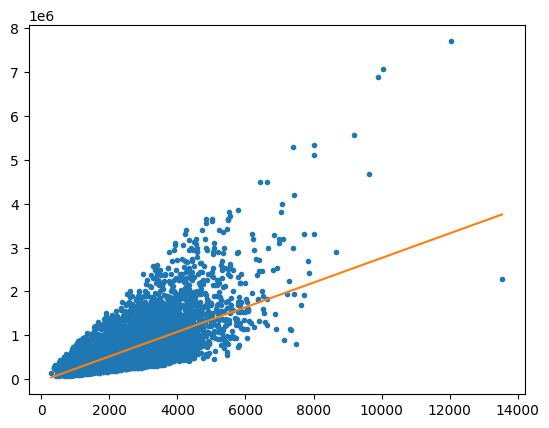

In [8]:
# sns.scatterplot(x='sqft_living^1', y='price', data=poly1_data)
plt.plot(
    poly1_data['sqft_living_1'],
    poly1_data['price'],
    '.'
)
plt.plot(
    poly1_data['sqft_living_1'],
    model1.predict(poly1_data[['sqft_living_1']]),
    # '-'
)
plt.show()

## 2nd Degree Polynomial

Now that you have plotted the results using a 1st degree polynomial, try it again using a 2nd degree and 3rd degree polynomial. Look at the fitted lines, do they appear as you would expect?

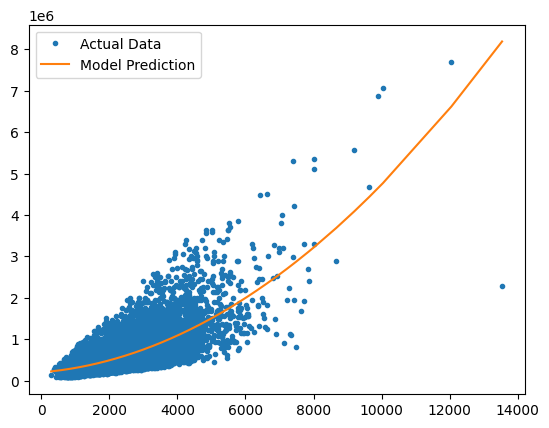

In [9]:
# defining degree
degree = 2
sqft_degree = str(f'sqft_living_{degree}')

# assembling the dataframe
poly_data = polynomial_df(data['sqft_living'], degree)
poly_data['price'] = data['price']

# computing weights
features=[]
for i in range(1, degree+1):
    features.append(str(f'sqft_living_{i}'))
model = LinearRegression().fit(poly_data[features], poly_data['price'])

# plotting
plt.plot(
    poly_data['sqft_living_1'],
    poly_data['price'],
    '.',
    label='Actual Data'
)
plt.plot(
    poly_data['sqft_living_1'],
    model.predict(poly_data[features]),
    '-',
    label="Model Prediction"
)
plt.legend()
plt.show()

# storing variables
poly2_data = poly_data
model2 = model

## 3rd Degree Polynomial

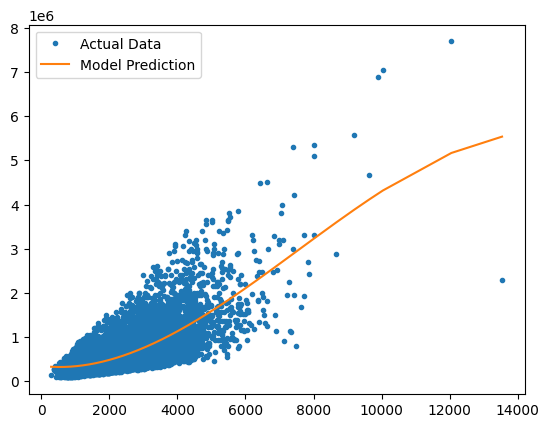

In [11]:
# defining degree
degree = 3
sqft_degree = str(f'sqft_living_{degree}')

# assembling the dataframe
poly_data = polynomial_df(data['sqft_living'], degree)
poly_data['price'] = data['price']

# computing weights
features=[]
for i in range(1, degree+1):
    features.append(str(f'sqft_living_{i}'))
model = LinearRegression().fit(poly_data[features], poly_data['price'])

# plotting
plt.plot(
    poly_data['sqft_living_1'],
    poly_data['price'],
    '.',
    label='Actual Data'
)
plt.plot(
    poly_data['sqft_living_1'],
    model.predict(poly_data[features]),
    '-',
    label="Model Prediction"
)
plt.legend()
plt.show()

# storing variables
poly3_data = poly_data
model3 = model

## 15th Degree Polynomial

Now try a 15th degree polynomial. Print out the coefficients and look at the resulted fitted line. Do you think this degree is appropriate for these data? If we were to use a different subset of the data do you think we would get pretty much the same curve?

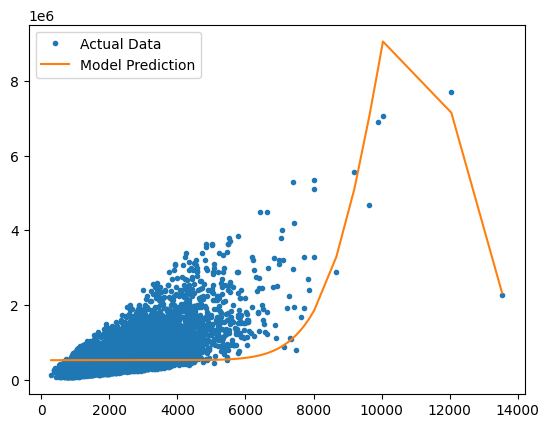

In [12]:
# defining degree
degree = 15
sqft_degree = str(f'sqft_living_{degree}')

# assembling the dataframe
poly_data = polynomial_df(data['sqft_living'], degree)
poly_data['price'] = data['price']

# computing weights
features=[]
for i in range(1, degree+1):
    features.append(str(f'sqft_living_{i}'))
model = LinearRegression().fit(poly_data[features], poly_data['price'])

# plotting
plt.plot(
    poly_data['sqft_living_1'],
    poly_data['price'],
    '.',
    label='Actual Data'
)
plt.plot(
    poly_data['sqft_living_1'],
    model.predict(poly_data[features]),
    '-',
    label="Model Prediction"
)
plt.legend()
plt.show()

# storing variables
poly15_data = poly_data
model15 = model

In [13]:
# printig out the coefficients
print (model15.coef_)

[ 4.56404164e-91 -6.23778993e-50  2.78846958e-56  2.78197724e-88
  1.19863929e-74  2.68575522e-71  2.26147568e-67  1.85900299e-63
  1.47144115e-59  1.09771012e-55  7.43509038e-52  4.23015577e-48
  1.61618577e-44 -2.49283826e-48  9.59718336e-53]


## Subsetting The Data

Estimate a 15th degree polynomial on all 4 sets, plot the results and view the coefficients for all four models.

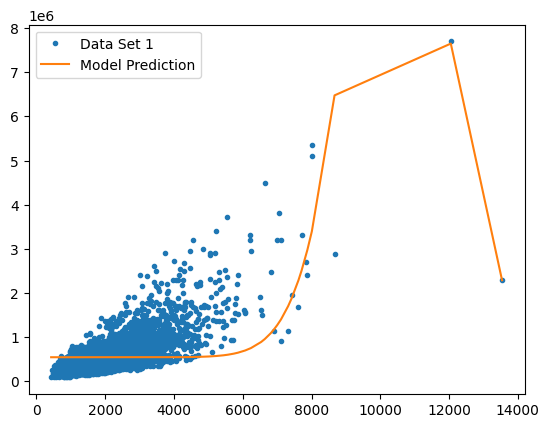

Model From Data Set 1 Coefficients:
 [ 3.05794168e-90  2.21229713e-49  8.63658779e-55  1.21888907e-88
  3.23082736e-74  1.10376020e-70  8.37724029e-67  6.23411957e-63
  4.49156442e-59  3.06938763e-55  1.91749300e-51  1.01335180e-47
  3.62176959e-44 -5.63501661e-48  2.18641116e-52] 



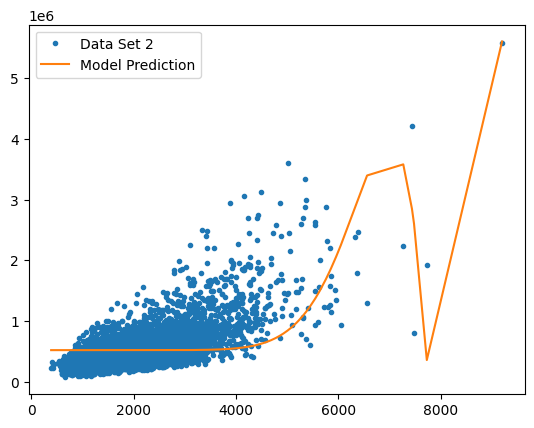

Model From Data Set 2 Coefficients:
 [ 7.68464024e-87 -1.99441117e-48 -2.14445539e-54 -3.18618382e-58
  2.54591694e-71  5.83714559e-68  3.15586748e-64  1.66523773e-60
  8.46916752e-57  4.06681213e-53  1.77699535e-49  6.53830287e-46
  1.61970330e-42 -3.86821043e-46  2.29271135e-50] 



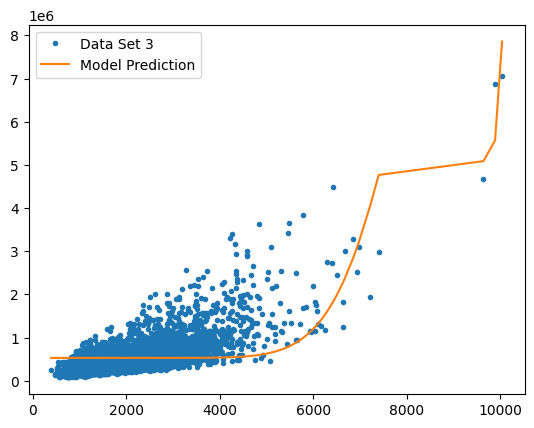

Model From Data Set 3 Coefficients:
 [ 2.83751934e-88 -3.80811713e-49 -2.99942712e-55 -3.98272978e-59
  1.57170169e-72  4.27896676e-69  2.68009626e-65  1.63911362e-61
  9.66435015e-58  5.38044653e-54  2.72563636e-50  1.16253248e-46
  3.33756141e-43 -6.76238818e-47  3.43132932e-51] 



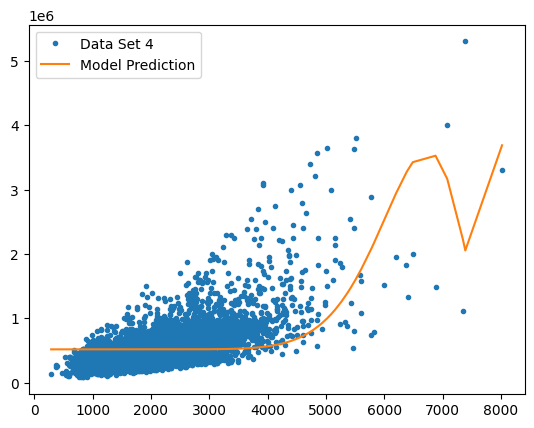

Model From Data Set 4 Coefficients:
 [ 2.94708250e-86  3.47667202e-49  2.17164928e-54  1.08147476e-83
  9.72346146e-63  1.69639204e-67  8.64417332e-64  4.29436906e-60
  2.05346827e-56  9.25550645e-53  3.78869479e-49  1.30313047e-45
  3.01068269e-42 -7.77465042e-46  5.02199311e-50] 



In [14]:
# defining degree
degree = 15
sqft_degree = str(f'sqft_living_{degree}')

x = 0
for set_x in (set_1, set_2, set_3, set_4):
    x+=1
    # assembling the dataframe
    poly_data = polynomial_df(set_x['sqft_living'], degree)
    poly_data['price'] = set_x['price']

    # computing weights
    features=[]
    for i in range(1, degree+1):
        features.append(str(f'sqft_living_{i}'))
    model = LinearRegression().fit(poly_data[features], poly_data['price'])

    # plotting
    plt.plot(
        poly_data['sqft_living_1'],
        poly_data['price'],
        '.',
        label=f'Data Set {x}'
    )
    plt.plot(
        poly_data['sqft_living_1'],
        model.predict(poly_data[features]),
        '-',
        label="Model Prediction"
    )
    plt.legend()
    plt.show()

    # printing coefficients
    print ("Model From Data Set", x, "Coefficients:\n", model.coef_, "\n")

**Quiz Question**: Is the sign (positive or negative) for power_15 the same in all four models?

In [15]:
print ("Answer: Yes, it is the same in all four models")

Answer: Yes, it is the same in all four models


**Quiz Question**: True/False the plotted fitted lines look the same in all four plots

In [16]:
print ("False")

False


## Assessing Performance / Cross Validation

Since the “best” polynomial degree is unknown to us we will use cross validation to select the best degree.

Now for each degree from 1 to 15:
- Build an polynomial data set using train_data[‘sqft_living’] as the feature and the current degree
- Add train_data[‘price’] as a column to your polynomial data set
- Learn a model on TRAINING data to predict ‘price’ based on your polynomial data set at the current degree
- Compute the RSS on VALIDATION for the current model (print or save the RSS)

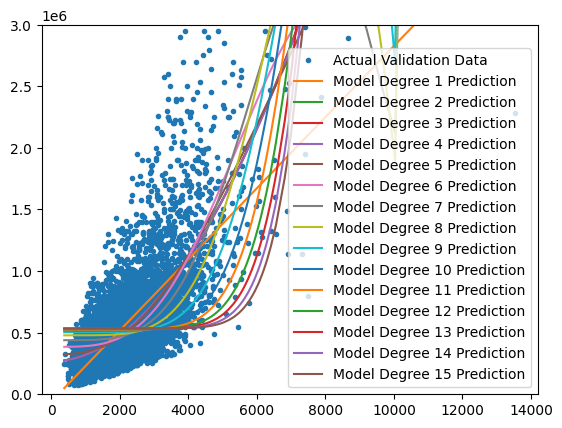

In [32]:
# scatter ploting of training data
plt.plot(
    valid_data['sqft_living'],
    valid_data['price'],
    '.',
    label='Actual Validation Data'
)

# hold  models and rss values
rss = []
models = []

# defining degree
for degree in range(1,16):

    # assembling the dataframes
    train_polydata = polynomial_df(train_data['sqft_living'], degree)
    train_polydata['price'] = train_data['price']
    valid_polydata = polynomial_df(valid_data['sqft_living'], degree)
    valid_polydata['price'] = valid_data['price']

    # get feature names
    features=[f'sqft_living_{i}' for i in range(1, degree+1)]

    # train on training data
    model = LinearRegression().fit(train_polydata[features], train_polydata['price'])
    models.append(model)

    # predicting on validation data
    predictions = model.predict(valid_polydata[features])

    # calculating rss
    new_rss = np.sum((valid_polydata['price'] - predictions) ** 2)
    rss.append(new_rss)

    # plotting
    plt.plot(
        valid_polydata['sqft_living_1'],
        predictions,
        '-',
        label=f'Model Degree {degree} Prediction'
    )

plt.ylim(0, 3000000) # zoom in to reasonable house prices
plt.legend()
plt.show()

In [33]:
for item in rss:
    print (item, "\n")

629097886299585.8 

623955062706517.8 

625820280251937.1 

628340053616990.5 

699826959364095.1 

1128396888129213.5 

2765582085491995.0 

6813331623885587.0 

1.5275792721377682e+16 

3.54798684118464e+16 

9.145865021456618e+16 

2.575119501235668e+17 

7.616230021244595e+17 

2.2975609249225956e+18 

6.955038096479833e+18 



**Quiz Question**: Which degree (1, 2, …, 15) had the lowest RSS on Validation data?

In [34]:
print ("Answer: Degree 2")

Answer: Degree 2


Now that you have selected a degree compute the RSS on TEST data for the model with the best degree from the Validation data.

**Quiz Question**: what is the RSS on TEST data for the model with the degree selected from Validation data? 

In [38]:
new_test_data = polynomial_df(test_data['sqft_living'], 2)
new_test_data['price'] = test_data['price']
test_predictions = models[2-1].predict(new_test_data[['sqft_living_1', 'sqft_living_2']])
test_rss = np.sum((new_test_data['price'] - test_predictions) ** 2)
print ("Answer:", test_rss)

Answer: 135542039274080.42
